In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# ======================================
# 03_baselines_TFIDF_ML.ipynb
# ======================================

# 1. Imports
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 2. Load Data

PREPROCESSED_TRAIN_CSV = '/content/drive/MyDrive/440_proj/Preprocess_outputs/uptaded_train_preprocessed.csv'
PREPROCESSED_TEST_CSV = '/content/drive/MyDrive/440_proj/Preprocess_outputs/uptaded_test_preprocessed.csv'

train_df = pd.read_csv(PREPROCESSED_TRAIN_CSV)
test_df = pd.read_csv(PREPROCESSED_TEST_CSV)

# print(train_df.shape, test_df.shape)
# train_df.head()

# Use clean_text_classical for BoW/TF-IDF
X_train_texts = train_df["clean_text_classical"].values
y_train = train_df["Class"].values

X_test_texts = test_df["clean_text_classical"].values
y_test = test_df["Class"].values

print("Train size:", len(X_train_texts))
print("Test size:", len(X_test_texts))

# 3. Utility Functions
def evaluate_preds(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"{model_name} — Accuracy: {acc:.4f}, F1: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()
    return acc, f1

# Store results
results = []


Train size: 280003
Test size: 59999


In [9]:
# Features and labels
X_train_texts = train_df["clean_text_classical"].fillna("").astype(str)
X_test_texts  = test_df["clean_text_classical"].fillna("").astype(str)

y_train = train_df["Class"]
y_test  = test_df["Class"]

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)


In [10]:
# BoW
bow_vectorizer = CountVectorizer(max_features=20000, ngram_range=(1,2))  # tune ngram_range & max_features
X_train_bow = bow_vectorizer.fit_transform(X_train_texts)
X_test_bow  = bow_vectorizer.transform(X_test_texts)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))  # tune here
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_texts)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_texts)

print("BoW shape:", X_train_bow.shape, "TF-IDF shape:", X_train_tfidf.shape)


BoW shape: (280003, 20000) TF-IDF shape: (280003, 20000)


# Logistic Regression

## Logistic Regression + BoW

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (BoW) — Accuracy: 0.6408, F1: 0.6394

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.46      0.45      0.46      6000
  Computers & Internet       0.79      0.82      0.80      6000
 Education & Reference       0.46      0.45      0.45      6000
 Entertainment & Music       0.61      0.66      0.63      6000
Family & Relationships       0.65      0.68      0.66      5999
                Health       0.71      0.72      0.71      6000
 Politics & Government       0.71      0.67      0.69      6000
 Science & Mathematics       0.64      0.66      0.65      6000
     Society & Culture       0.52      0.48      0.50      6000
                Sports       0.84      0.84      0.84      6000

              accuracy                           0.64     59999
             macro avg       0.64      0.64      0.64     59999
          weighted avg       0.64      0.64      0.64     59999



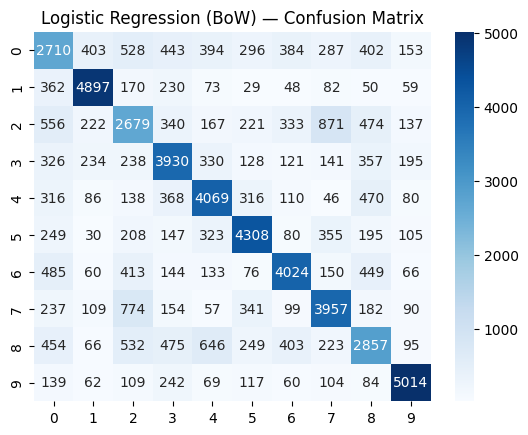

In [11]:
log_reg_bow = LogisticRegression(max_iter=300, C=1.0)  # tune C (regularization), max_iter
log_reg_bow.fit(X_train_bow, y_train)
y_pred = log_reg_bow.predict(X_test_bow)
results.append(evaluate_preds("Logistic Regression (BoW)", y_test, y_pred))



## Logistic Regression + TF-IDF


Logistic Regression (TF-IDF) — Accuracy: 0.6988, F1: 0.6966

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.56      0.51      0.54      6000
  Computers & Internet       0.83      0.85      0.84      6000
 Education & Reference       0.55      0.51      0.53      6000
 Entertainment & Music       0.67      0.69      0.68      6000
Family & Relationships       0.69      0.75      0.72      5999
                Health       0.75      0.78      0.76      6000
 Politics & Government       0.76      0.74      0.75      6000
 Science & Mathematics       0.69      0.74      0.72      6000
     Society & Culture       0.59      0.55      0.57      6000
                Sports       0.86      0.85      0.86      6000

              accuracy                           0.70     59999
             macro avg       0.70      0.70      0.70     59999
          weighted avg       0.70      0.70      0.70     59999



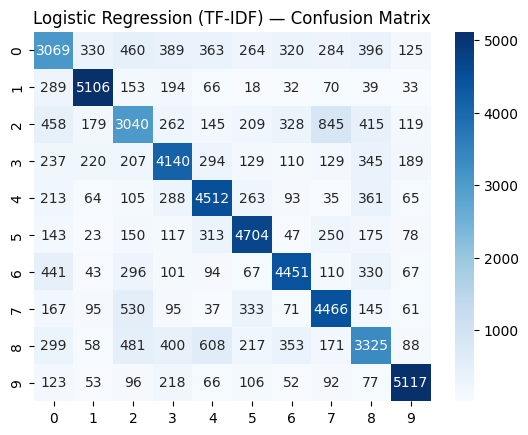

In [12]:

log_reg_tfidf = LogisticRegression(max_iter=300, C=1.0)  # tune
log_reg_tfidf.fit(X_train_tfidf, y_train)
y_pred = log_reg_tfidf.predict(X_test_tfidf)
results.append(evaluate_preds("Logistic Regression (TF-IDF)", y_test, y_pred))

# Naive Bayes

## Naive Bayes + BoW

Naive Bayes (BoW) — Accuracy: 0.6777, F1: 0.6746

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.57      0.50      0.53      6000
  Computers & Internet       0.79      0.85      0.82      6000
 Education & Reference       0.55      0.45      0.50      6000
 Entertainment & Music       0.60      0.69      0.64      6000
Family & Relationships       0.61      0.78      0.68      5999
                Health       0.74      0.76      0.75      6000
 Politics & Government       0.75      0.71      0.73      6000
 Science & Mathematics       0.72      0.71      0.71      6000
     Society & Culture       0.59      0.52      0.55      6000
                Sports       0.86      0.81      0.83      6000

              accuracy                           0.68     59999
             macro avg       0.68      0.68      0.67     59999
          weighted avg       0.68      0.68      0.67     59999



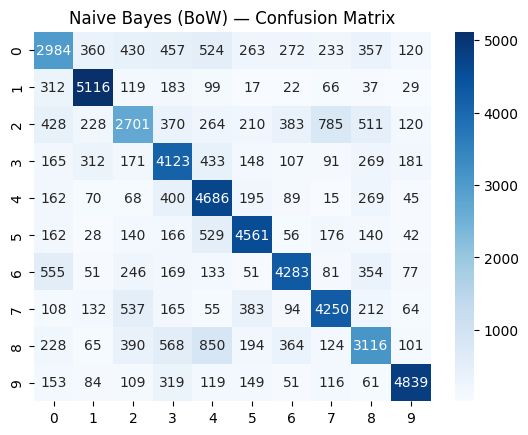

Naive Bayes (TF-IDF) — Accuracy: 0.6861, F1: 0.6824

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.57      0.51      0.54      6000
  Computers & Internet       0.80      0.86      0.83      6000
 Education & Reference       0.57      0.45      0.50      6000
 Entertainment & Music       0.64      0.67      0.66      6000
Family & Relationships       0.62      0.79      0.69      5999
                Health       0.73      0.78      0.75      6000
 Politics & Government       0.75      0.73      0.74      6000
 Science & Mathematics       0.71      0.73      0.72      6000
     Society & Culture       0.59      0.54      0.56      6000
                Sports       0.87      0.81      0.84      6000

              accuracy                           0.69     59999
             macro avg       0.68      0.69      0.68     59999
          weighted avg       0.68      0.69      0.68     59999



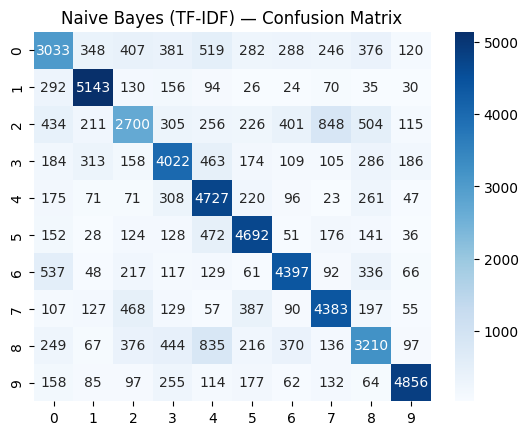

In [13]:
nb_bow = MultinomialNB(alpha=1.0)  # tune alpha (smoothing)
nb_bow.fit(X_train_bow, y_train)
y_pred = nb_bow.predict(X_test_bow)
results.append(evaluate_preds("Naive Bayes (BoW)", y_test, y_pred))




## Naive Bayes + TF-IDF

Naive Bayes (TF-IDF) — Accuracy: 0.6861, F1: 0.6824

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.57      0.51      0.54      6000
  Computers & Internet       0.80      0.86      0.83      6000
 Education & Reference       0.57      0.45      0.50      6000
 Entertainment & Music       0.64      0.67      0.66      6000
Family & Relationships       0.62      0.79      0.69      5999
                Health       0.73      0.78      0.75      6000
 Politics & Government       0.75      0.73      0.74      6000
 Science & Mathematics       0.71      0.73      0.72      6000
     Society & Culture       0.59      0.54      0.56      6000
                Sports       0.87      0.81      0.84      6000

              accuracy                           0.69     59999
             macro avg       0.68      0.69      0.68     59999
          weighted avg       0.68      0.69      0.68     59999



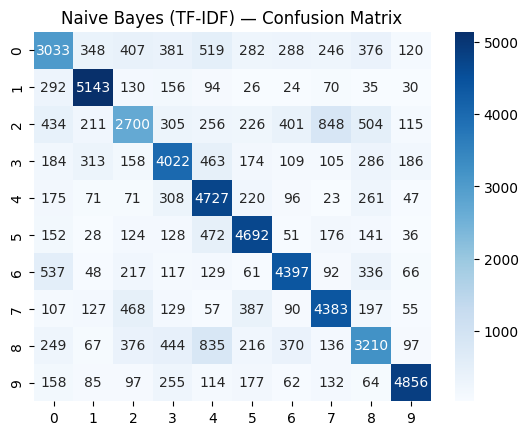

In [15]:
nb_tfidf = MultinomialNB(alpha=1.0)  # tune
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred = nb_tfidf.predict(X_test_tfidf)
results.append(evaluate_preds("Naive Bayes (TF-IDF)", y_test, y_pred))

# Random Forest

## Random Forest + BoW

Random Forest (BoW) — Accuracy: 0.5765, F1: 0.5725

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.59      0.36      0.45      6000
  Computers & Internet       0.69      0.81      0.74      6000
 Education & Reference       0.52      0.31      0.39      6000
 Entertainment & Music       0.64      0.46      0.53      6000
Family & Relationships       0.54      0.74      0.62      5999
                Health       0.67      0.64      0.66      6000
 Politics & Government       0.65      0.67      0.66      6000
 Science & Mathematics       0.35      0.72      0.47      6000
     Society & Culture       0.63      0.40      0.49      6000
                Sports       0.79      0.66      0.72      6000

              accuracy                           0.58     59999
             macro avg       0.61      0.58      0.57     59999
          weighted avg       0.61      0.58      0.57     59999



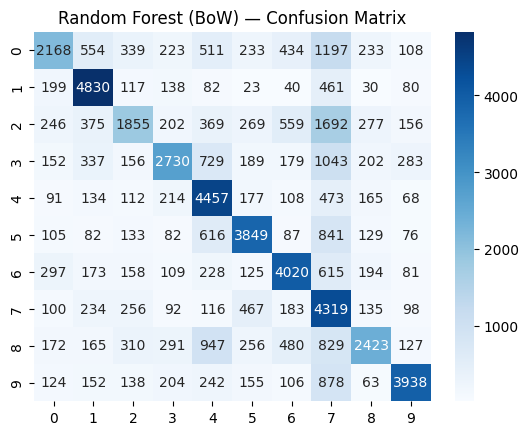

In [16]:
rf_bow = RandomForestClassifier(n_estimators=200, max_depth=30, n_jobs=-1, random_state=42)
# tune n_estimators, max_depth
rf_bow.fit(X_train_bow, y_train)
y_pred = rf_bow.predict(X_test_bow)
results.append(evaluate_preds("Random Forest (BoW)", y_test, y_pred))



## Random Forest + TF-IDF

Random Forest (TF-IDF) — Accuracy: 0.5777, F1: 0.5729

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.59      0.37      0.45      6000
  Computers & Internet       0.69      0.80      0.74      6000
 Education & Reference       0.56      0.30      0.39      6000
 Entertainment & Music       0.61      0.47      0.53      6000
Family & Relationships       0.54      0.75      0.63      5999
                Health       0.67      0.64      0.66      6000
 Politics & Government       0.65      0.67      0.66      6000
 Science & Mathematics       0.36      0.71      0.48      6000
     Society & Culture       0.62      0.41      0.49      6000
                Sports       0.77      0.66      0.71      6000

              accuracy                           0.58     59999
             macro avg       0.60      0.58      0.57     59999
          weighted avg       0.60      0.58      0.57     59999



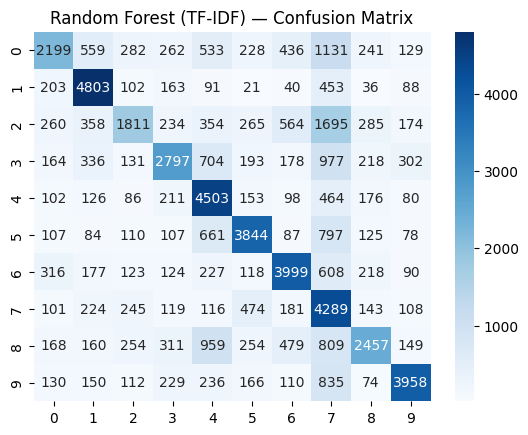

In [17]:
rf_tfidf = RandomForestClassifier(n_estimators=200, max_depth=30, n_jobs=-1, random_state=42)
rf_tfidf.fit(X_train_tfidf, y_train)
y_pred = rf_tfidf.predict(X_test_tfidf)
results.append(evaluate_preds("Random Forest (TF-IDF)", y_test, y_pred))